# EDA for Synthetic E-Commerce Dataset

This notebook verifies the realism and causal logic embedded in our synthetic dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')
sns.set_palette("husl")

## 1. Load the Data

We load the newly generated synthetic dataset.

In [2]:
data_path = "data/synthetic_ecommerce_orders.csv"
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
    display(df.head())
else:
    print(f"File not found: {data_path}. Please run synthetic_data_generation.py first.")

Loaded dataset with 5000 rows and 20 columns.


,order_id,order_date,customer_id,product_id,product_category,product_price,quantity,order_value,discount_percentage,discount_amount,customer_city,warehouse_city,distance_km,is_remote_area,shipping_mode,expected_delivery_days,actual_delivery_days,delivery_delay,is_returned,return_reason
0,1,2024-02-11,233,P052,Electronics,1614,2,3228,30,968.4,Kolkata,Kolkata,26,0,Express,2,2,0,0,NO_RETURN
1,2,2024-07-21,232,P021,Home,1303,1,1303,10,130.3,Bangalore,Hyderabad,458,0,Express,4,4,0,1,NOT_AS_DESCRIBED
2,3,2024-07-18,87,P008,Home,1188,2,2376,0,0.0,Kolkata,Kolkata,26,0,Express,2,2,0,0,NO_RETURN
3,4,2024-01-28,211,P007,Electronics,5396,1,5396,10,539.6,Chennai,Bangalore,318,0,Standard,5,5,0,1,WRONG_ITEM
4,5,2024-11-24,223,P008,Home,1224,1,1224,0,0.0,Delhi,Mumbai,1185,0,Express,2,6,4,1,DELIVERY_DELAY


## 2. Basic Distributions

Checking if price is right-skewed and quantities follow expected probabilities.

c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


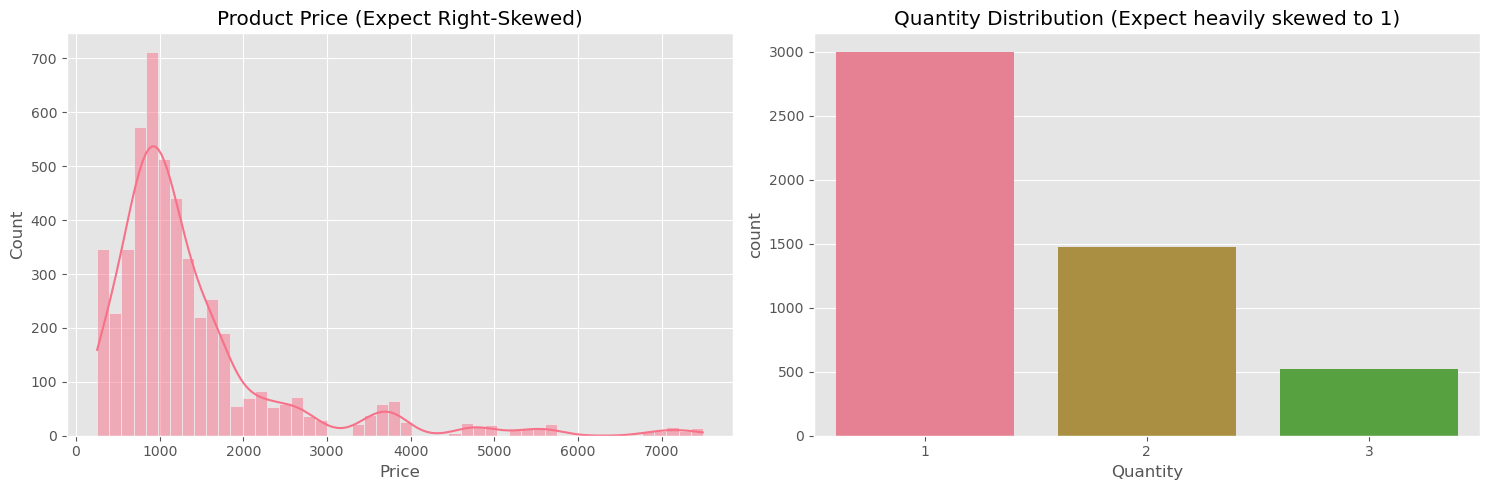

Quantity proportions:
quantity
1    0.5992
2    0.2958
3    0.1050
Name: proportion, dtype: float64


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['product_price'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Product Price (Expect Right-Skewed)')
ax[0].set_xlabel('Price')

sns.countplot(data=df, x='quantity', ax=ax[1])
ax[1].set_title('Quantity Distribution (Expect heavily skewed to 1)')
ax[1].set_xlabel('Quantity')

plt.tight_layout()
plt.show()

print("Quantity proportions:")
print(df['quantity'].value_counts(normalize=True))

## 3. Target Variable: Return Rate

Verify the general baseline return rate ranges between 10% and 40%.


Overall Return Rate: 34.80%


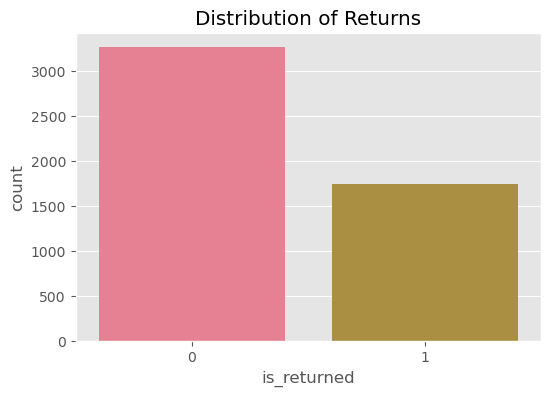

In [5]:
return_rate = df['is_returned'].mean()
print(f"\nOverall Return Rate: {return_rate:.2%}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_returned')
plt.title('Distribution of Returns')
plt.show()

## 4. Causal Relationships

1. **Delivery Delay -> Returns**: More delays = more returns.
2. **Discount -> Returns**: Higher discounts = more impulse buys = higher returns.

c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


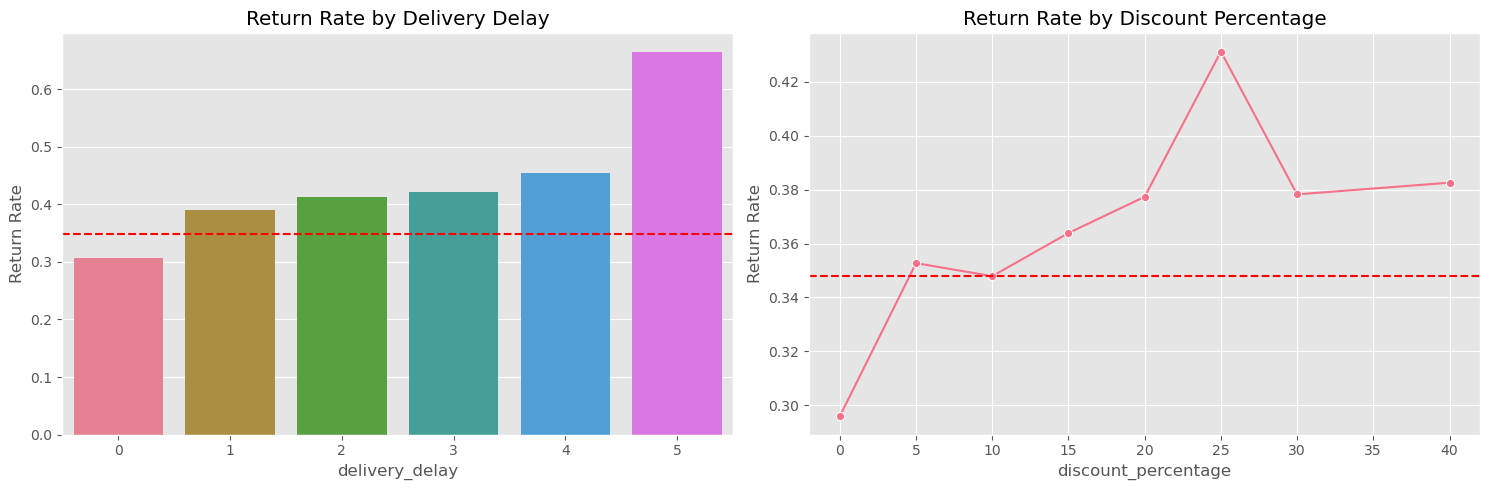

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Delay vs Returns
delay_returns = df.groupby('delivery_delay')['is_returned'].mean().reset_index()
sns.barplot(data=delay_returns, x='delivery_delay', y='is_returned', ax=ax[0])
ax[0].set_title('Return Rate by Delivery Delay')
ax[0].set_ylabel('Return Rate')
ax[0].axhline(y=return_rate, color='r', linestyle='--')

# Discount vs Returns
discount_returns = df.groupby('discount_percentage')['is_returned'].mean().reset_index()
sns.lineplot(data=discount_returns, x='discount_percentage', y='is_returned', marker='o', ax=ax[1])
ax[1].set_title('Return Rate by Discount Percentage')
ax[1].set_ylabel('Return Rate')
ax[1].axhline(y=return_rate, color='r', linestyle='--')

plt.tight_layout()
plt.show()

## 5. Category Effects

Check if Clothing has higher returns, predominantly driven by size/fit issues.

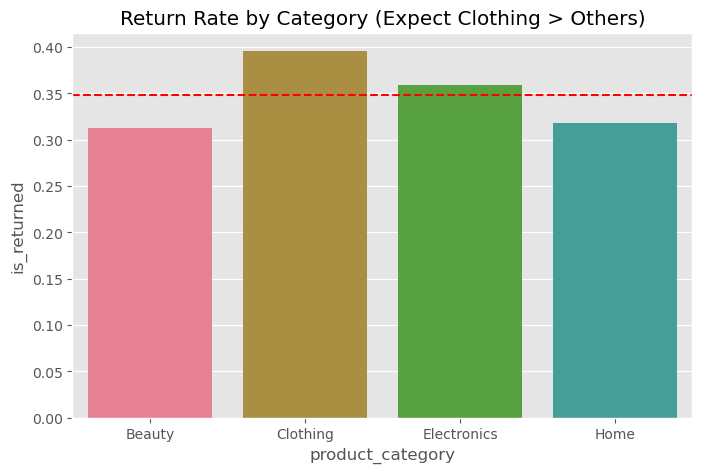

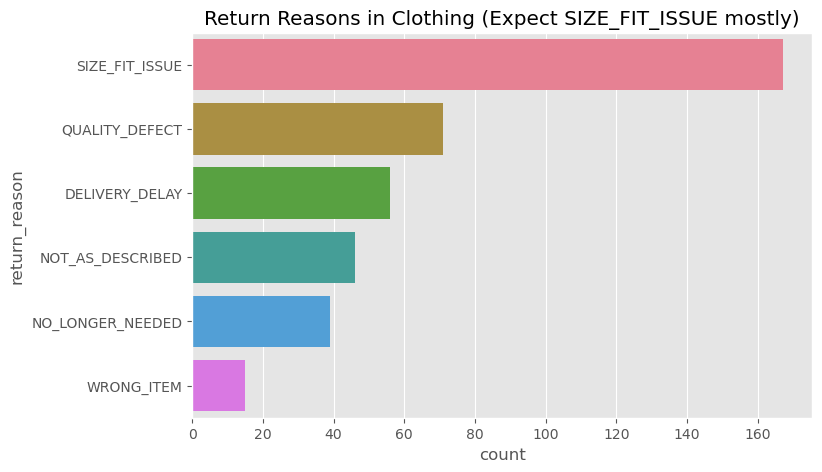

In [7]:
cat_returns = df.groupby('product_category')['is_returned'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=cat_returns, x='product_category', y='is_returned')
plt.title('Return Rate by Category (Expect Clothing > Others)')
plt.axhline(y=return_rate, color='r', linestyle='--')
plt.show()

returned_clothing = df[(df['is_returned'] == 1) & (df['product_category'] == 'Clothing')]
plt.figure(figsize=(8, 5))
sns.countplot(data=returned_clothing, y='return_reason', 
              order=returned_clothing['return_reason'].value_counts().index)
plt.title('Return Reasons in Clothing (Expect SIZE_FIT_ISSUE mostly)')
plt.show()

## 6. Logistics & Geography

Longer distances or remote areas should lead to higher average delays.

C:\Users\Hp\AppData\Local\Temp\ipykernel_8376\1260328239.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_delay = df.groupby('distance_bin')['delivery_delay'].mean().reset_index()
c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


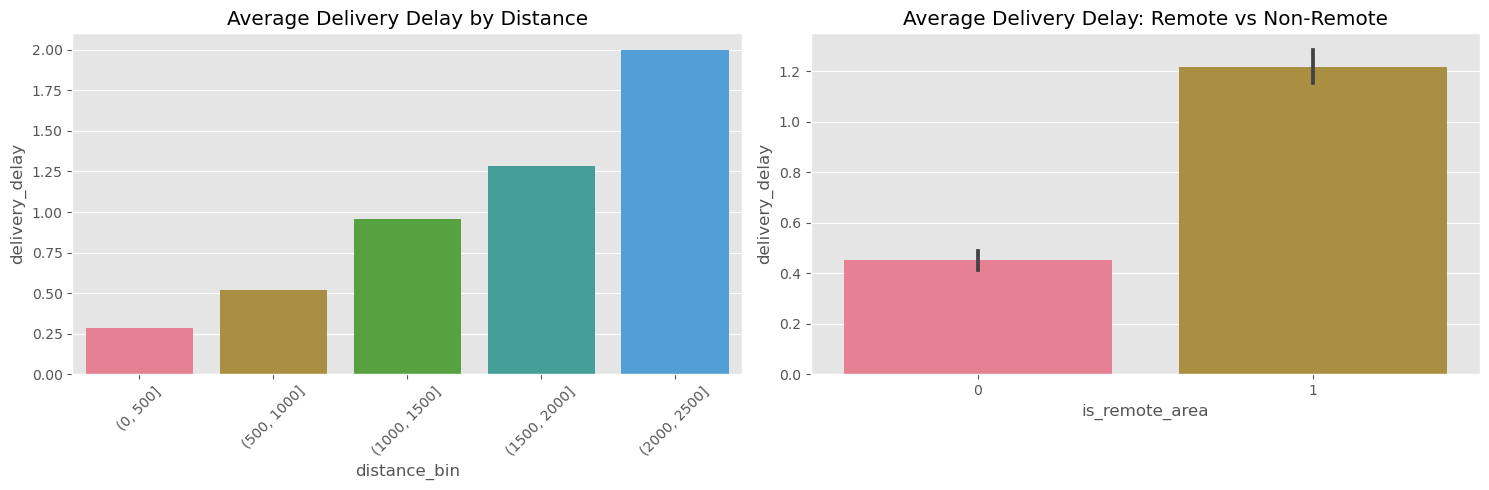

In [8]:
df['distance_bin'] = pd.cut(df['distance_km'], bins=[0, 500, 1000, 1500, 2000, 2500])
dist_delay = df.groupby('distance_bin')['delivery_delay'].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=dist_delay, x='distance_bin', y='delivery_delay', ax=ax[0])
ax[0].set_title('Average Delivery Delay by Distance')
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='is_remote_area', y='delivery_delay', ax=ax[1])
ax[1].set_title('Average Delivery Delay: Remote vs Non-Remote')

plt.tight_layout()
plt.show()

## 7. Multicollinearity & Variance Inflation Factor (VIF)

According to `preprocessing_advanced.md`, we must check for multicollinearity among the numerical features. Identifying feature sets with `VIF > 10` is critical for some linear models.
We expect derived features (e.g. `order_value` from `product_price` x `quantity`, `actual_delivery_days` from `expected + delay`) to be highly correlated.

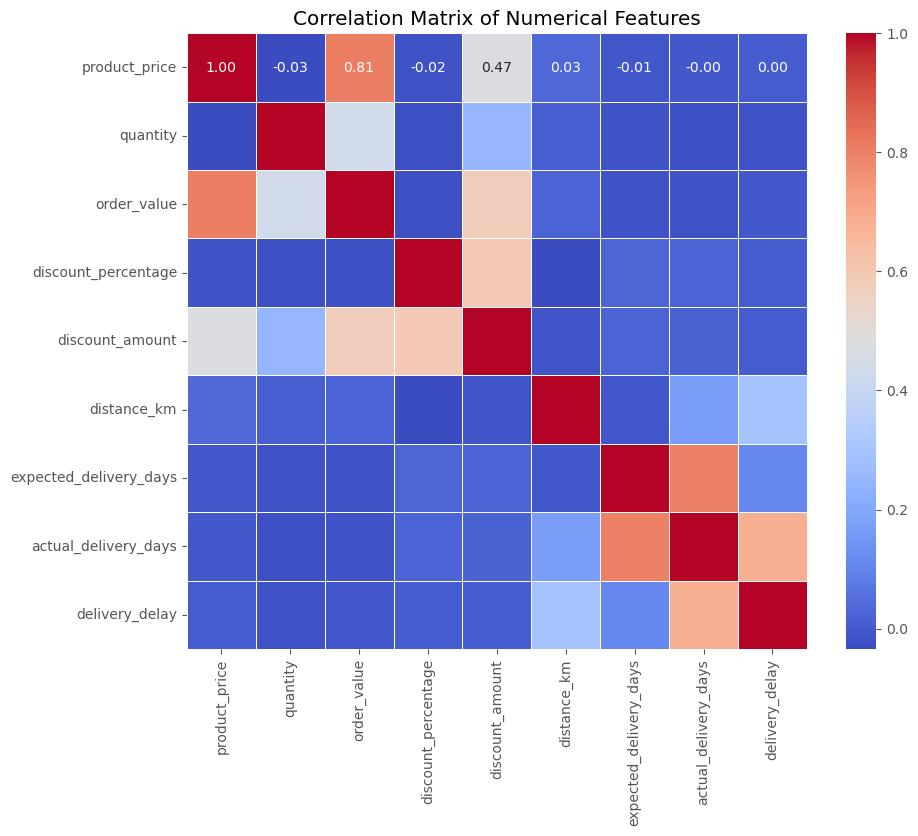

In [3]:
numeric_cols = ['product_price', 'quantity', 'order_value', 'discount_percentage', 'discount_amount', 
                'distance_km', 'expected_delivery_days', 'actual_delivery_days', 'delivery_delay']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Replace any zero or inf values to avoid VIF errors
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(df[numeric_cols].values, i) for i in range(len(numeric_cols))]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data.to_markdown(index=False))

| feature                |       VIF |
|:-----------------------|----------:|
| expected_delivery_days | inf       |
| actual_delivery_days   | inf       |
| delivery_delay         | inf       |
| order_value            |  14.7002  |
| product_price          |  10.2446  |
| quantity               |   8.55804 |
| discount_amount        |   4.36694 |
| discount_percentage    |   4.26728 |
| distance_km            |   4.03638 |


c:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\Hp\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Multicollinearity Findings
1. **Infinite VIFs**: `expected_delivery_days`, `actual_delivery_days`, and `delivery_delay` show perfect multicollinearity ($VIF = \infty$) because `actual_delivery_days = expected_delivery_days + delivery_delay`. To prevent linear model instability, we should use only **two** of these (or strictly `delivery_delay` which is the causal driver).
2. **High VIFs ($VIF > 10$)**: `order_value` and `product_price` have VIFs $\sim 14.7$ and $\sim 10.2$ respectively. This confirms the mathematical dependency `order_value = product_price * quantity`.
3. **Moderate VIFs ($5 \le VIF \le 10$)**: `quantity` has a VIF around $8.5$. 

**Actionable Insight for Modeling**: 
- If using tree-based models (e.g., XGBoost, LightGBM), this multicollinearity is generally not an issue as they are robust to it. 
- If using linear models (e.g., Logistic Regression), we must drop `order_value`, `actual_delivery_days`, and potentially `discount_amount` in favor of their component features.